## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [2]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [2]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [2]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [1]:
def simulazione_lanci(N):
    lanci=[np.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


NameError: name 'np' is not defined

In [6]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

KeyError: 0

<Figure size 1000x600 with 0 Axes>

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

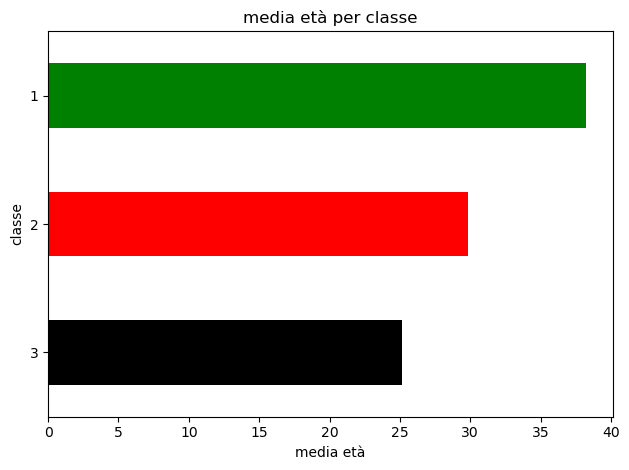

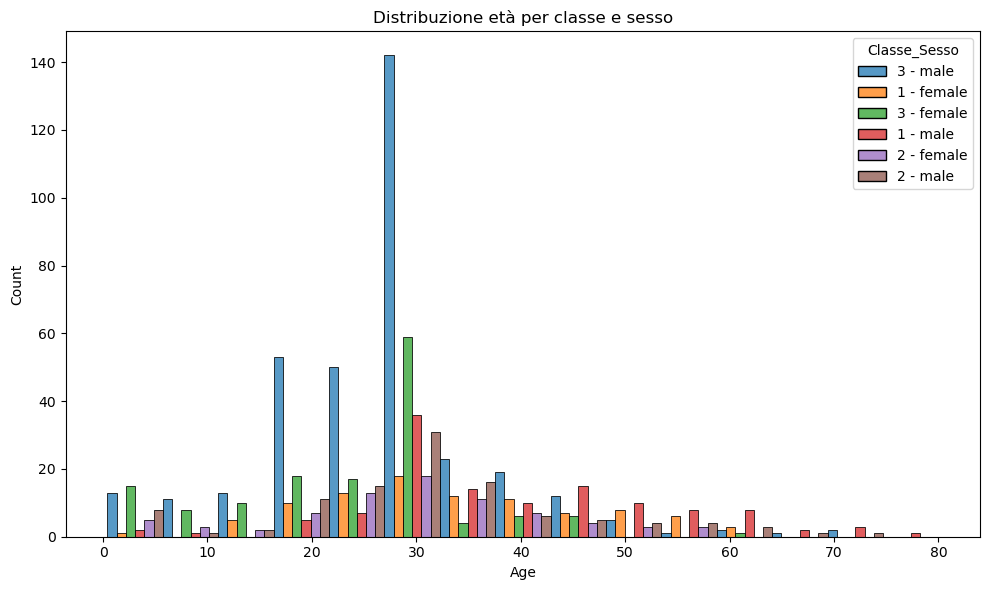

In [ ]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
#print(df)

#conteggio per colonna numero di NaN 
#print(df.isna().sum())

#sostituzione NaN
#df["Embarked"].fillna(df["Embarked"].mode())
df_filled = df.fillna({"Embarked": df["Embarked"].mode()[0]})
#print(df_filled.isna().sum())

#controllo righe doppie
print(f"righe doppie {df.duplicated().sum()}")

#controllo età media per Pclass
media_classe = df.groupby("Pclass")["Age"].mean().sort_values(ascending=True)

#riempimento di age con media
df["Age"] = df["Age"].fillna(df["Age"].mean())

#visualizzazione età per classe
media_classe.plot(kind="barh", color=["black","red","green"])
plt.title("media età per classe")
plt.xlabel("media età")
plt.ylabel("classe")
plt.tight_layout()
plt.show()

#controllo età media per classe e diviso per uomini e donne usando seaborn
df["Classe_Sesso"] = df["Pclass"].astype(str) + " - " + df["Sex"]

plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Age", hue="Classe_Sesso", multiple="dodge", bins=15)
plt.title("Distribuzione età per classe e sesso")
plt.tight_layout()
plt.show()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

Campioni per specie:  species
setosa        50
versicolor    50
virginica     50
dtype: int64

Lunghezza e larghezza media per specie: 
             petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026



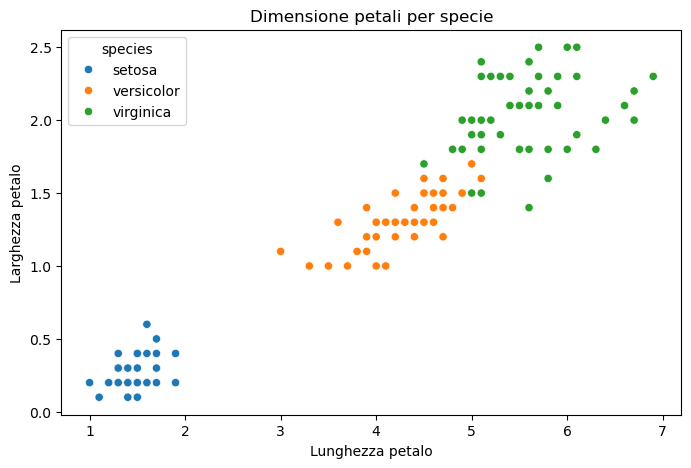

Area media del petalo per specie: 
 species
setosa         0.3656
versicolor     5.7204
virginica     11.2962
Name: petal_area, dtype: float64


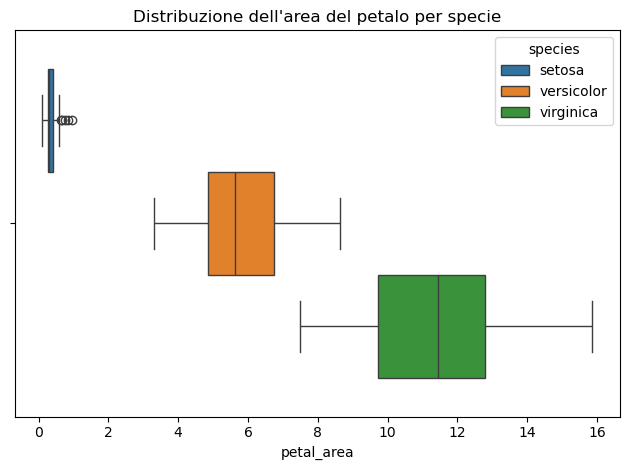

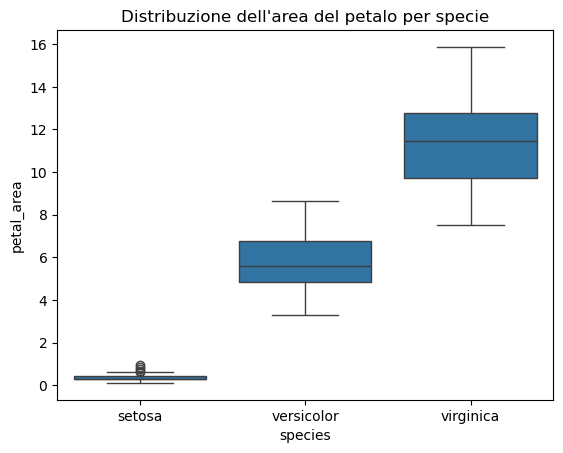

,sepal_length,sepal_width,petal_length,petal_width,species,petal_area
0,5.1,3.5,1.4,0.2,setosa,0.28
1,4.9,3.0,1.4,0.2,setosa,0.28
2,4.7,3.2,1.3,0.2,setosa,0.26
3,4.6,3.1,1.5,0.2,setosa,0.30
4,5.0,3.6,1.4,0.2,setosa,0.28


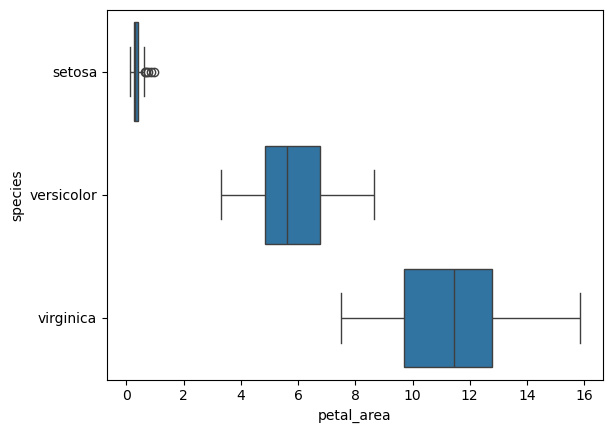

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
#1
print("Campioni per specie: ", df.groupby("species").size())
print()

#2
print("Lunghezza e larghezza media per specie: \n", df.groupby("species")[["petal_length", "petal_width"]].mean())
print()

#3 Dimensione dei petali per specie
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.title("Dimensione petali per specie")
plt.xlabel("Lunghezza petalo")
plt.ylabel("Larghezza petalo")
plt.show()

#4
df["petal_area"] = df["petal_length"]*df["petal_width"]
print("Area media del petalo per specie: \n", df.groupby("species")["petal_area"].mean())

#5
sns.boxplot(data=df,
            x="petal_area",
            hue="species")
plt.title("Distribuzione dell'area del petalo per specie")
plt.tight_layout()
plt.show()

#5 verticale
sns.boxplot(
    data=df,
    x="species",
    y="petal_area"
)
plt.title("Distribuzione dell'area del petalo per specie")
plt.show()

#5 orizzontale
sns.boxplot(
    data=df,
    x="petal_area",
    y="species"
)

df.head()